This notebook is to analyze the residuals.
Sum of Squares Due to Error.   This statistic measures the total deviation of the response values from the fit to the response values.
It is also called the summed square of residuals and is usually labeled as SSE.

In [1]:
import pandas as pd
from pathlib import Path
from matplotlib import pyplot as plt
import numpy as np
import csv

In [21]:
base_path = Path('C:\\Users\\thinkBookUser\\Desktop\\Screening_Data_Analyzed')
base_path = Path('K:\\SurfDrive\\')
resultpath = Path(base_path, 'Screening_Data_Mutable\\2019\\12\\05\\results')
resultfile = 'B02_tau.csv'
fitfile = 'B02_fit.csv'
fit = pd.read_csv(Path(resultpath,fitfile))
lifetimetraces = np.loadtxt(Path(resultpath,resultfile))
frameinterval = 2
forskendpoint = False
nroi = lifetimetraces.shape[0]
ntime = lifetimetraces.shape[1]

In [22]:
fit.head()

,Unnamed: 0,start(ns),range(ns),breakdown time(s),midpoint(s),start tau(ns),e_start,e_range,e_halftime,e_midpoint,error,condition,e_breakdown time
0,0,3.184448,-0.381033,46.380482,75.845244,2.784362,0.021909,0.024789,NaN,2.278778,1.0,PDE2A,7.480400
1,1,3.207942,-0.650081,40.482304,53.025595,2.587977,0.055220,0.056781,NaN,2.226530,16.0,PDE2A,4.886525
2,2,3.160251,-0.442894,53.136639,77.435671,2.740165,0.010640,0.012136,NaN,1.012488,0.0,PDE2A,3.290838
3,3,3.268633,-0.843838,33.060746,47.910198,2.404709,0.035887,0.036525,NaN,0.891518,17.0,PDE2A,1.808467
4,4,3.174127,-0.359997,41.965271,80.939859,2.803255,0.011608,0.013618,NaN,1.356389,0.0,PDE2A,4.666976


In [23]:
fit_sel = fit[fit['breakdown time(s)'] > 150]
fit_sel = fit_sel[fit_sel['error']==0]
fit_sel.head()

,Unnamed: 0,start(ns),range(ns),breakdown time(s),midpoint(s),start tau(ns),e_start,e_range,e_halftime,e_midpoint,error,condition,e_breakdown time


In [24]:
def fit_function(x, a, b, c, d):
    return a + b / (1 + np.exp(-4 * (x - d)/c)) 

In [25]:
trace_id = 50
fit_vals= fit.loc[trace_id,:]
fit_vals

Unnamed: 0                   50
start(ns)                 3.178
range(ns)             -0.422192
breakdown time(s)       49.3773
midpoint(s)             89.8022
start tau(ns)            2.7438
e_start              0.00713788
e_range               0.0089753
e_halftime                  NaN
e_midpoint             0.840864
error                         0
condition                 PDE2A
e_breakdown time        3.00162
Name: 50, dtype: object

In [26]:
xdat = np.arange(0, ntime * frameinterval, frameinterval)
print(xdat)
print('n_x =', len(xdat))

[  0   2   4   6   8  10  12  14  16  18  20  22  24  26  28  30  32  34
  36  38  40  42  44  46  48  50  52  54  56  58  60  62  64  66  68  70
  72  74  76  78  80  82  84  86  88  90  92  94  96  98 100 102 104 106
 108 110 112 114 116 118 120 122 124 126 128 130 132 134 136 138 140 142
 144 146 148 150 152 154 156 158 160 162 164 166 168 170 172 174 176 178
 180 182 184 186]
n_x = 94


In [27]:
ydat = lifetimetraces[trace_id]
print(ydat)
print('n_y =', len(ydat))

[2.77316659 2.77857346 2.70881905 2.72807107 2.75974408 2.75015522
 2.70223752 2.73291851 2.73795956 2.68828909 2.73633901 2.73503928
 2.77085779 2.71410579 2.72446352 3.15975633 3.19787648 3.17706894
 3.18448276 3.14608173 3.17112898 3.18782567 3.1542917  3.14864476
 3.16079827 3.17787784 3.17782232 3.12644618 3.16720593 3.15583016
 3.14576788 3.14373874 3.13003892 3.13651171 3.10691589 3.11458371
 3.10314846 3.09392013 3.06358727 3.0612473  3.05425029 3.0506282
 3.02964143 3.01446615 3.01089548 2.93221059 2.96524991 2.93055475
 2.90612886 2.90000742 2.89610667 2.8671423  2.85232274 2.84480414
 2.83444584 2.85982301 2.80253456 2.83397157 2.80024734 2.79058683
 2.82900687 2.81981771 2.79041027 2.81191446 2.76691265 2.76542677
 2.75899582 2.75300488 2.74347787 2.74053855 2.75660252 2.76066135
 2.76266331 2.74875417 2.78825738 2.74245723 2.73483099 2.75474575
 2.68668418 2.74214301 2.7721747  2.75669683 2.76249425 2.73075205
 2.77150145 2.77076205 2.7468381  2.75668054 2.78189932 2.72942

In [28]:
yfit = fit_function(xdat,fit_vals['start(ns)'],fit_vals['range(ns)'],fit_vals['breakdown time(s)'],fit_vals['midpoint(s)'])
print(yfit)
print('n_yfit =', len(yfit))

[3.17770779 3.17765643 3.17759604 3.17752506 3.17744162 3.17734355
 3.17722829 3.17709284 3.17693368 3.17674667 3.17652699 3.17626896
 3.17596596 3.17561022 3.17519268 3.17470277 3.17412815 3.17345449
 3.1726651  3.17174069 3.17065892 3.16939407 3.16791659 3.16619269
 3.16418395 3.16184692 3.15913284 3.15598746 3.15235106 3.14815874
 3.14334107 3.13782527 3.1315369  3.12440233 3.11635199 3.10732434
 3.0972707  3.08616057 3.0739872  3.06077282 3.04657308 3.0314797
 3.01562096 2.9991593  2.98228591 2.96521258 2.94816134 2.93135312
 2.91499636 2.89927716 2.88435151 2.87034058 2.85732882 2.84536499
 2.83446522 2.82461761 2.81578763 2.80792364 2.80096217 2.79483253
 2.78946071 2.78477244 2.78069546 2.77716118 2.77410569 2.77147033
 2.76920193 2.76725282 2.76558056 2.76414768 2.76292126 2.76187255
 2.76097652 2.76021147 2.75955864 2.75900185 2.75852717 2.75812265
 2.75777801 2.75748448 2.75723454 2.75702174 2.7568406  2.75668644
 2.75655524 2.7564436  2.75634862 2.75626781 2.75619906 2.75614

In [29]:
y_sigma = np.random.random(len(ydat))
print(y_sigma)
print('n_ysigma =', len(y_sigma))

[0.80915376 0.72091149 0.49379128 0.14282509 0.49333223 0.3283849
 0.72286756 0.70434757 0.22213471 0.2874038  0.58894679 0.39175913
 0.13424977 0.40850526 0.05163283 0.99413472 0.79617056 0.41440517
 0.30967297 0.36277027 0.68898311 0.72513251 0.44495719 0.28211261
 0.34951194 0.9063482  0.41191382 0.39239848 0.75700663 0.90009621
 0.44543617 0.95130737 0.90386475 0.659396   0.38833689 0.64203527
 0.72965532 0.46865673 0.77205713 0.64635876 0.12249122 0.33948298
 0.14009633 0.36413627 0.92796212 0.91680215 0.23394807 0.42281322
 0.62040737 0.85943337 0.74529155 0.35243698 0.69635544 0.79431838
 0.06237726 0.70526666 0.75754863 0.19492545 0.31121084 0.9562034
 0.14764685 0.98387784 0.64775055 0.71255735 0.75927304 0.77142501
 0.65959989 0.53335936 0.8664546  0.53253413 0.99453358 0.91657013
 0.37629678 0.79361832 0.20642866 0.79214504 0.94003634 0.44512981
 0.49960377 0.19392939 0.82619996 0.11628001 0.48867551 0.5935938
 0.18025487 0.19581725 0.35300673 0.86335345 0.29747567 0.4666881

In [30]:
# find the fit-range
fitrange = np.zeros(shape=2, dtype=int)
mean_trace = np.mean(lifetimetraces, axis=0)

d_mean_trace = np.diff(mean_trace)
fitrange[0] = np.argmax(mean_trace[0:int(150 / frameinterval)])  # maximum in the first 150 seconds
fitrange[1] = ntime
if forskendpoint:
    # 3 frames before maximum increase after peak.
    fitrange[1] = fitrange[0] + np.argmax(d_mean_trace[fitrange[0]:]) - 1

xdat_selected = xdat[fitrange[0]:fitrange[1]]
ydat_selected = ydat[fitrange[0]:fitrange[1]]
yfit_selected = yfit[fitrange[0]:fitrange[1]]
y_sigma_selected = y_sigma[fitrange[0]:fitrange[1]]

Unnamed: 0                   50
start(ns)                 3.178
range(ns)             -0.422192
breakdown time(s)       49.3773
midpoint(s)             89.8022
start tau(ns)            2.7438
e_start              0.00713788
e_range               0.0089753
e_halftime                  NaN
e_midpoint             0.840864
error                         0
condition                 PDE2A
e_breakdown time        3.00162
Name: 50, dtype: object

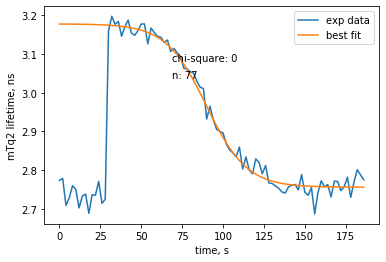

In [31]:
plt.xlabel("time, s")
plt.ylabel("mTq2 lifetime, ns")
plt.plot(xdat,ydat, label="exp data")
plt.plot(xdat,yfit, label="best fit")
plt.legend()
chisq = sum(((ydat_selected-yfit_selected)/y_sigma_selected)**2)
plt.figtext(0.42, 0.69, "chi-square: %.0f"%chisq)
n = len(ydat_selected)
plt.figtext(0.42, 0.63, "n: %.0f"%n)
fit_vals

In [32]:
yresid = ydat - yfit
print(yresid)

[-4.04541203e-01 -3.99082968e-01 -4.68776991e-01 -4.49453993e-01
 -4.17697540e-01 -4.27188330e-01 -4.74990770e-01 -4.44174328e-01
 -4.38974117e-01 -4.88457580e-01 -4.40187985e-01 -4.41229681e-01
 -4.05108168e-01 -4.61504426e-01 -4.50729163e-01 -1.49464351e-02
  2.37483315e-02  3.61445885e-03  1.18176564e-02 -2.56589598e-02
  4.70060699e-04  1.84316018e-02 -1.36248894e-02 -1.75479269e-02
 -3.38567232e-03  1.60309192e-02  1.86894792e-02 -2.95412777e-02
  1.48548643e-02  7.67142371e-03  2.42680778e-03  5.91347470e-03
 -1.49797648e-03  1.21093761e-02 -9.43610272e-03  7.25937375e-03
  5.87776331e-03  7.75955614e-03 -1.03999292e-02  4.74478543e-04
  7.67721136e-03  1.91485039e-02  1.40204772e-02  1.53068508e-02
  2.86095714e-02 -3.30019906e-02  1.70885662e-02 -7.98366524e-04
 -8.86749797e-03  7.30258276e-04  1.17551524e-02 -3.19827295e-03
 -5.00608277e-03 -5.60850807e-04 -1.93791771e-05  3.52053961e-02
 -1.32530663e-02  2.60479272e-02 -7.14827506e-04 -4.24570212e-03
  3.95461631e-02  3.50452

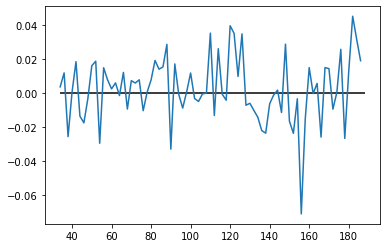

In [35]:
#here I tried to just plot the residuals between the xperimental values and the fitted values
plt.plot(xdat[fitrange[0]:fitrange[1]], yresid[fitrange[0]:fitrange[1]])
#plt.plot(x, yresid)
plt.hlines(0, frameinterval*fitrange[0], frameinterval*fitrange[1])

In [36]:
#  The residual sum of squares is used to help you decide if a statistical model is a good fit for your data. 
SSresid = sum(yresid[fitrange[0]:fitrange[1]]**2)
# The Total SS (TSS or SST) tells you how much variation there is in the dependent variable. SStotal = Σ((Yi – mean of Y)**2).
# or also people use: SStotal = n*var(Y)
SStotal = len(ydat[fitrange[0]:fitrange[1]]) * np.var(ydat)
Rsq = 1-(SSresid/SStotal)
print("SSresid = %.2f"%SSresid)
print("SStotal = %.2f"%SStotal)
print("Rsq = %.2f"%Rsq)
# this formula works in the more linear area of our curve, BUT
# but Kees pointed out, that we must use the variance in data aqusition, not of actual y values like is here in the formul

SSresid = 0.03
SStotal = 2.23
Rsq = 0.99


In [41]:
#The root-mean-square deviation (RMSD): sqrt(SSresid/n)

RMSD = np.sqrt(SSresid / len(ydat[fitrange[0]:fitrange[1]]))
print("RMSD = %.3f ns"%RMSD)

RMSD = 0.019 ns


In [42]:
#  Here I try to use our simulated std of y-values, but up there np.var(y) results in a single number, here y_sigma is an array, does not work directly
# And if I take the np.var(y_sigma) then I am again back to totally simulating the Rsq
SSresid = sum(yresid[fitrange[0]:fitrange[1]]**2)
SStotal = len(ydat[fitrange[0]:fitrange[1]]) * np.var(y_sigma[fitrange[0]:fitrange[1]])
Rsq = 1-(SSresid/SStotal)
print("SSresid = %.2f"%SSresid)
print("SStotal = %.2f"%SStotal)
print("Rsq = %.2f"%Rsq)

SSresid = 0.03
SStotal = 5.31
Rsq = 0.99


In [35]:
#If this were a case for linear regression
from scipy.stats import *
# for demo I will take the steepest part of our curve
start_lin=25
stop_lin=45
slope, intercept, r_value, p_value, std_err = linregress(x[start_lin:stop_lin],y[start_lin:stop_lin])
print("Rsq = %.2f"%r_value**2)


Rsq = 0.97
